In [2]:
import numpy as np
from qiskit.synthesis.evolution import SuzukiTrotter
from qiskit import QuantumCircuit,transpile
from qiskit.quantum_info import SparsePauliOp,Statevector,Operator
# from qiskit_ibm_runtime import (EstimatorV2 as Estimator,SamplerV2 as Sampler)
from qiskit_aer import AerSimulator
from qiskit.circuit.library import PauliEvolutionGate
from scipy.linalg import svd
import time as CPUTime
from itertools import product
import time
from itertools import product
import matplotlib.pyplot as plt

In [3]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

# Qubit 数量
N = 5

# TFIM 参数
J = 1.0  # ZZ coupling
h = 1.0  # transverse field

# 构造 Pauli 字符串和系数
pauli_list = []
coeffs = []

# 最近邻 ZZ 项：-J * Z_i Z_{i+1}
for i in range(N - 1):
    pauli_str = ['I'] * N
    pauli_str[i] = 'Z'
    pauli_str[i + 1] = 'Z'
    pauli_list.append(''.join(pauli_str))
    coeffs.append(-J)

# 横场 X 项：-h * X_i
for i in range(N):
    pauli_str = ['I'] * N
    pauli_str[i] = 'X'
    pauli_list.append(''.join(pauli_str))
    coeffs.append(-h)

# 构造 SparsePauliOp Hamiltonian
Hamil = SparsePauliOp.from_list(list(zip(pauli_list, coeffs)))

# 模拟器
simulator = AerSimulator(method='statevector')

# 时间演化参数
dtime = 0.1
N_time = 2000


In [4]:
from scipy.sparse.linalg import eigsh
H_sparse=Hamil.to_matrix(sparse=True)
eigval, eigvec = eigsh(H_sparse, k=1, which='SA') 
X_sum = SparsePauliOp(
    ['XIIII', 'IXIII', 'IIXII', 'IIIXI', 'IIIIX'],
    coeffs=[1] * 5
).to_matrix(sparse=True)


In [5]:
# X_sum.toarray()


array([[0.+0.j, 1.+0.j, 1.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       ...,
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 1.+0.j, 1.+0.j, 0.+0.j]])

In [6]:
eigvec=eigvec.flatten()

In [7]:
eigvec

array([0.4325762 +0.0618084j , 0.22541916+0.03220888j,
       0.14433362+0.02062303j, 0.18728501+0.02676011j,
       0.13718545+0.01960166j, 0.08578485+0.01225732j,
       0.11131306+0.0159049j , 0.18728501+0.02676011j,
       0.14433362+0.02062303j, 0.08067126+0.01152667j,
       0.05800619+0.00828818j, 0.08578485+0.01225732j,
       0.11131306+0.0159049j , 0.08067126+0.01152667j,
       0.12137219+0.01734219j, 0.22541916+0.03220888j,
       0.22541916+0.03220888j, 0.12137219+0.01734219j,
       0.08067126+0.01152667j, 0.11131306+0.0159049j ,
       0.08578485+0.01225732j, 0.05800619+0.00828818j,
       0.08067126+0.01152667j, 0.14433362+0.02062303j,
       0.18728501+0.02676011j, 0.11131306+0.0159049j ,
       0.08578485+0.01225732j, 0.13718545+0.01960166j,
       0.18728501+0.02676011j, 0.14433362+0.02062303j,
       0.22541916+0.03220888j, 0.4325762 +0.0618084j ])

In [8]:
# Statevector(qc0).data.shape

In [9]:
# phi_activate.flatten().shape

In [10]:
# ini_state=Statevector(qc0).data

In [11]:
Nq=N
qc0=QuantumCircuit(Nq)
# ini_state=Statevector(qc0).data
# print(ini_state)
ini_state=eigvec
# print(ini_state)

In [12]:



evolution_gate = PauliEvolutionGate(Hamil, dtime)
qc0.append(evolution_gate, list(range(N)))
qc0=transpile(qc0, backend=simulator)
U_dt=Operator(qc0).data


In [13]:
U_dt.shape

(32, 32)

In [14]:
pauli_list = []
coeffs = []

for i in range(N):
    pauli_str = ['I'] * N
    pauli_str[i] = 'Z'
    pauli_list.append(''.join(pauli_str))
    coeffs.append(1.0)

# 构造 SparsePauliOp 并转换为矩阵
# Obs_op = SparsePauliOp(pauli_list, coeffs=coeffs).to_matrix()
Obs_op=X_sum

In [15]:
pauli_list

['ZIIII', 'IZIII', 'IIZII', 'IIIZI', 'IIIIZ']

In [16]:
# 单量子比特的泡利矩阵
I = np.array([[1, 0], [0, 1]])
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

# 构造 n 量子比特的泡利基底
def pauli_basis_xyzi(n):
    
    # 基本泡利矩阵的组合
    paulis = [ X, Y, Z ,I]
    basis = []
    for combination in product(paulis, repeat=n):
        # 对每个组合做 Kronecker 积（Kronecker product）
        mat = combination[0]
        for p in combination[1:]:
            mat = np.kron(mat, p)
        basis.append(mat)
    # 这里我们还需要给每个矩阵配个名字
    pauli_names = ['X', 'Y', 'Z','I']
    name_list=[]
    for names in product(pauli_names, repeat=n):
        combined_name=names[0]
        for p in names[1:]:
             combined_name+= p

        # print(f"Name: {combined_name}")
        name_list.append(combined_name)
    return basis,name_list
def pauli_basis_xyz(n):
    
    # 基本泡利矩阵的组合
    paulis = [ X, Y, Z]
    basis = []
    for combination in product(paulis, repeat=n):
        # 对每个组合做 Kronecker 积（Kronecker product）
        mat = combination[0]
        for p in combination[1:]:
            mat = np.kron(mat, p)
        basis.append(mat)
        
    # 这里我们还需要给每个矩阵配个名字
    pauli_names = ['X', 'Y', 'Z']
    name_list=[]
    for names in product(pauli_names, repeat=n):
        combined_name=names[0]
        for p in names[1:]:
             combined_name+= p

        # print(f"Name: {combined_name}")
        name_list.append(combined_name)
    return basis,name_list
# 获取 8 量子比特的泡利基底（256x256矩阵对应于 8 量子比特）

In [17]:
def coff_extract(Operator):
    # n_bas=2
    # num_fro=0
    coff_list=[]
    name_list=[]
    pauli_basis_matrices,matricesname  = pauli_basis_xyzi(Nq)
    for i_pauli,pauli_mat in enumerate(pauli_basis_matrices) : 
        # pauli_mat_complete=pauli_mat
        coff_list.append(np.trace(Operator@pauli_mat)/(2**Nq))   
    return coff_list,matricesname
def Oper_recon(Coff_n,Nq):

    i_coff=0
    Operator_n=np.zeros((2**Nq, 2**Nq))
    pauli_basis_matrices,matricesname  = pauli_basis_xyzi(Nq)
    for i_pauli,pauli_mat in enumerate(pauli_basis_matrices) : 

 
        Operator_n=pauli_mat*Coff_n[i_coff]+Operator_n  
        i_coff+=1
    return Operator_n

In [18]:
def coff_extract_trunc(n_bas,Operator):

    coff_list=[]
    name_list=[]
    pauli_basis_matrices,matricesname  = pauli_basis_xyz(n_bas)
    for num_fro in range(Nq+1-n_bas):
        
        for i_pauli,pauli_mat in enumerate(pauli_basis_matrices) : 
            pauli_mat_complete=pauli_mat
            pauli_name_complete=matricesname
            # print(pauli_mat)
            name=matricesname[i_pauli]
            for i_fro in range(num_fro):
                pauli_mat_complete=np.kron(I,pauli_mat_complete)
                name = "I" + name 
            for i_beh in range(Nq-num_fro-n_bas):
                pauli_mat_complete=np.kron(pauli_mat_complete,I)  
                name =  name+"I" 
            coff_list.append(np.trace(Operator@pauli_mat_complete)/(2**Nq))   
            name_list.append(name) 
    return coff_list,name_list


In [19]:
def Oper_recon_trunc(n_bas,Coff_n):
    # n_bas=1
    # Coff_n=coff_extract(n_bas,A_t)
    
    i_coff=0
    Operator_n=np.zeros((2**Nq, 2**Nq))
    for num_fro in range(Nq+1-n_bas):
        pauli_basis_matrices,matricesname = pauli_basis_xyz(n_bas)
        for i_pauli,pauli_mat in enumerate(pauli_basis_matrices) : 
            pauli_mat_complete=pauli_mat
            # print(pauli_mat)
            for i_fro in range(num_fro):
                pauli_mat_complete=np.kron(I,pauli_mat_complete)
            for i_beh in range(Nq-num_fro-n_bas):
                pauli_mat_complete=np.kron(pauli_mat_complete,I)   
            Operator_n=pauli_mat_complete*Coff_n[i_coff]+Operator_n  
            i_coff+=1
    return Operator_n
def Vec_recons_trunc(vec):
    
    Oper_rec=vec[0] *np.eye(2**Nq)+Oper_recon_trunc(1,vec[1:1+3*Nq])+Oper_recon_trunc(2,vec[1+3*Nq:])

    return Oper_rec

In [20]:
####truncate over  O_t=U_t_hc@Obs_op@U_t@Obs_op

# coff_t=[]
# ExV_t=[]
# coff_trunc_t=[]
# ExV_t_trunc=[]
# # ini_state
# ini_state_hc=ini_state.conj().T

# # coff_t.append(coff_extract(Obs_op) )
# # ExV_t.append(ini_state_hc@Obs_op@ini_state)
# # U_t=np.linalg.matrix_power(Udt, idt) 
# U_t=np.eye(2**Nq)
# for idt in range(0,N_time):
#     if idt%100==0:
#         print(idt/N_time)
#     U_t_hc=U_t.conj().T
#     O_t=U_t_hc@Obs_op@U_t@Obs_op
#     # coff_,name_full_all=coff_extract(O_t)
#     # coff_t.append(coff_ )
#     ExV_t.append(ini_state_hc@O_t@ini_state)

#     coff_trunc_0=np.trace(O_t)/(2**Nq)
#     name_0=["n of I"]
#     coff_trunc_1,name_1=coff_extract_trunc(1,O_t)
#     coff_trunc_2,name_2=coff_extract_trunc(2,O_t)
    
#     coff_trunc_all=[coff_trunc_0]+coff_trunc_1+coff_trunc_2
#     name_all=name_0+name_1+name_2
#     coff_trunc_t.append(coff_trunc_all)
#     ExV_t_trunc.append(ini_state_hc@Vec_recons_trunc(coff_trunc_all)@ini_state)
#     U_t=U_dt@U_t

In [21]:
#truncate over  O_t=U_t_hc@Obs_op@U_t

coff_t=[]
ExV_t=[]
coff_trunc_t=[]
ExV_t_trunc=[]
# ini_state
ini_state_hc=ini_state.conj().T

# coff_t.append(coff_extract(Obs_op) )
# ExV_t.append(ini_state_hc@Obs_op@ini_state)
# U_t=np.linalg.matrix_power(Udt, idt) 
U_t=np.eye(2**Nq)
for idt in range(0,N_time):
    if idt%100==0:
        print(idt/N_time)
    U_t_hc=U_t.conj().T
    O_t=U_t_hc@Obs_op@U_t
    # coff_,name_full_all=coff_extract(O_t)
    # coff_t.append(coff_ )
    ExV_t.append(ini_state_hc@O_t@Obs_op@ini_state)

    coff_trunc_0=np.trace(O_t)/(2**Nq)
    name_0=["n of I"]
    coff_trunc_1,name_1=coff_extract_trunc(1,O_t)
    coff_trunc_2,name_2=coff_extract_trunc(2,O_t)
    
    coff_trunc_all=[coff_trunc_0]+coff_trunc_1+coff_trunc_2
    name_all=name_0+name_1+name_2
    coff_trunc_t.append(coff_trunc_all)
    ExV_t_trunc.append(ini_state_hc@Vec_recons_trunc(coff_trunc_all)@Obs_op@ini_state)
    U_t=U_dt@U_t

0.0
0.05
0.1
0.15
0.2
0.25
0.3
0.35
0.4
0.45
0.5
0.55
0.6
0.65
0.7
0.75
0.8
0.85
0.9
0.95


In [22]:
# len(name_full_all)

In [23]:
# ExV_t

/Users/wiswolf/opt/anaconda3/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/wiswolf/opt/anaconda3/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


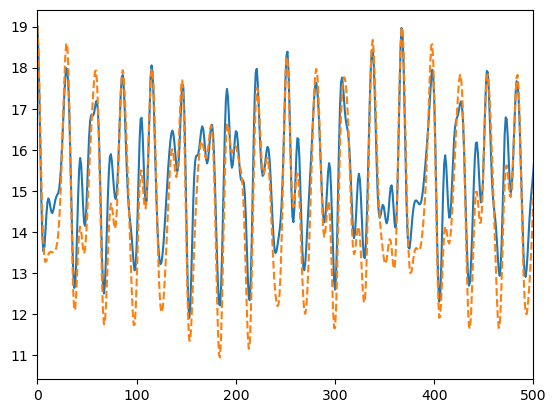

In [86]:
# plt.subplot(1,2,1)
# plt.plot(np.abs(coff_t))
# plt.xlim(0,40)
# plt.subplot(1,2,2)
plt.plot(ExV_t)
plt.plot(ExV_t_trunc,'--')
plt.xlim(0,500)
plt.show()


In [83]:
t_list=np.array(range(1,N_time+1))*dtime
np.savez("Coff_O_Data_", t_list=t_list
         ,coff_trunc_t=coff_trunc_t
         # ,coff_t=coff_t
         ,ini_state=ini_state  
         # ,name_full=name_full_all
         ,name_trunc=name_all
         ,X_sum=X_sum.toarray()
        )

In [80]:
X_sum.toarray()

array([[0.+0.j, 1.+0.j, 1.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       ...,
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 1.+0.j, 1.+0.j, 0.+0.j]])

In [26]:
qc0.draw()

┌──────────┐
q_0: ────────────────────────────────────■──────────┤ Rx(-0.2) ├
                                         │ZZ(-0.2)  ├──────────┤
q_1: ────────────────────────■───────────■──────────┤ Rx(-0.2) ├
                             │ZZ(-0.2)  ┌──────────┐└──────────┘
q_2: ────────────■───────────■──────────┤ Rx(-0.2) ├────────────
                 │ZZ(-0.2)  ┌──────────┐└──────────┘            
q_3: ─■──────────■──────────┤ Rx(-0.2) ├────────────────────────
      │ZZ(-0.2) ┌──────────┐└──────────┘                        
q_4: ─■─────────┤ Rx(-0.2) ├────────────────────────────────────
                └──────────┘

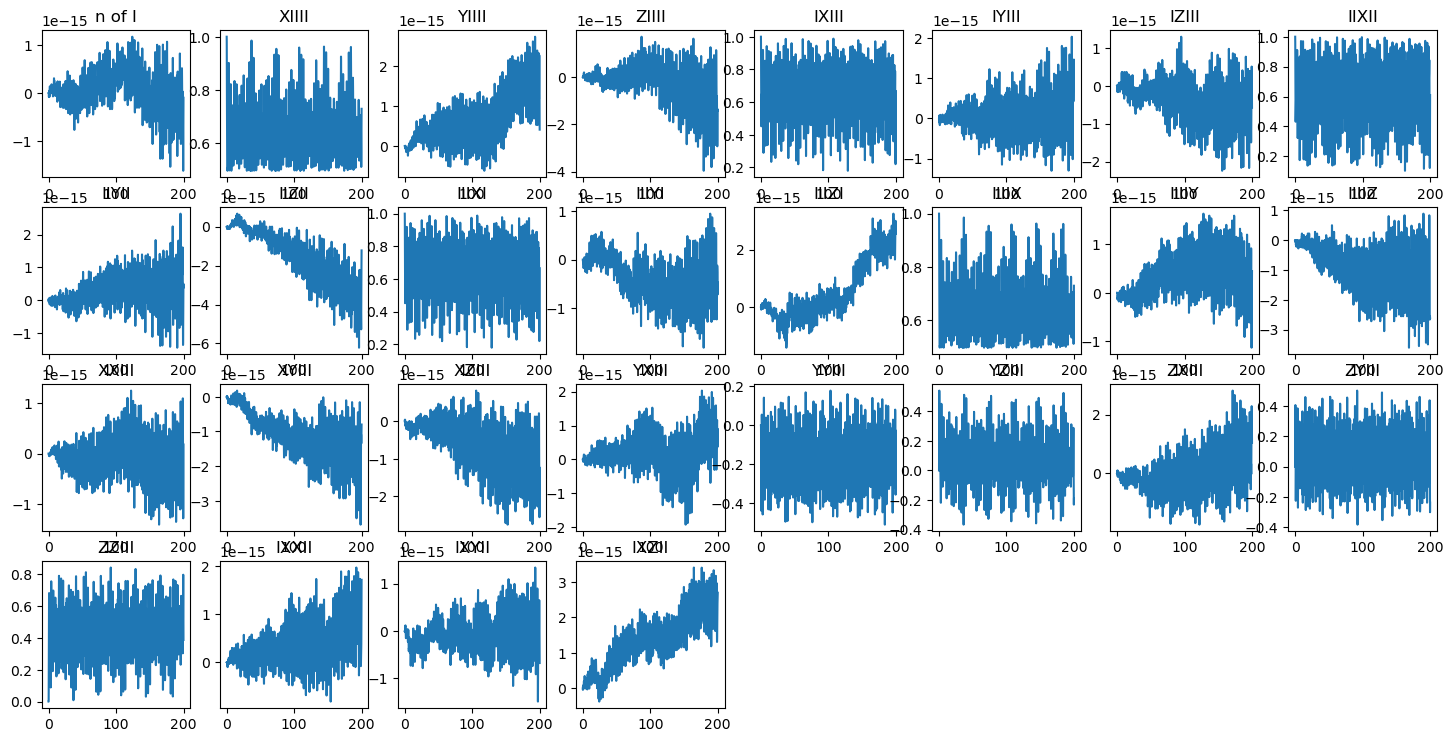

In [27]:
plt.figure(figsize=(18, 18))
time_list=np.array(range(1,N_time+1))*dtime
for ishow in range(28):
    plt.subplot(8,8,ishow+1)
    plt.plot(time_list,np.real(coff_trunc_t)[:,ishow])
    plt.title(name_all[ishow])
    # plt.plot(time_list,np.real(coff_trunc_t[:,ishow]))

In [28]:
# coff_extract_trunc(1,O_t)

In [29]:
# n_bas=1
# Operator=O_t



# coff_list=[]
# name_list=[]
# pauli_basis_matrices,matricesname  = pauli_basis_xyz(n_bas)
# for num_fro in range(Nq+1-n_bas):
    
#     for i_pauli,pauli_mat in enumerate(pauli_basis_matrices) : 
#         pauli_mat_complete=pauli_mat
#         pauli_name_complete=matricesname
#         # print(pauli_mat)
#         name=matricesname[i_pauli]
#         for i_fro in range(num_fro):
#             pauli_mat_complete=np.kron(I,pauli_mat_complete)
#             name = "I" + name 
#         for i_beh in range(Nq-num_fro-n_bas):
#             pauli_mat_complete=np.kron(pauli_mat_complete,I)  
#             name =  name+"I" 
#         coff_list.append(np.trace(Operator@pauli_mat_complete)/(2**Nq))   
#         name_list.append(name)

In [30]:
# coff_list

In [31]:
from scipy.interpolate import interp1d
def interpolated_fft(time_list, A_t_psi_rec_list, fs=20, kind='linear', fmax=3):
    """
    对非等间隔采样信号进行插值重采样，并计算其 FFT。

    参数：
    - time_list: 原始时间列表（非等间隔）
    - A_t_psi_rec_list: 原始信号（与 time_list 长度一致）
    - fs: 插值后的采样频率（Hz），默认 20Hz
    - kind: 插值类型（如 'linear' 或 'cubic'）
    - fmax: 返回频率范围的上限（Hz），默认只返回 0 ~ fmax 的频谱

    返回：
    - freqs_half: 频率数组（只包含正频率）
    - fft_amplitudes_half: 幅值数组（对应频率的幅度）
    """

    # 插值函数
    f_inter = interp1d(time_list, np.real(A_t_psi_rec_list), kind=kind)

    # 等间隔时间轴
    t_start, t_end = time_list[0], time_list[-1]
    t_new = np.arange(t_start, t_end, 1/fs)

    # 插值得到新信号
    signal = f_inter(t_new)

    # 计算 FFT
    fft_result = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1/fs)

    # 只取正频率部分
    half_n = len(signal) // 2
    freqs_half = freqs[:half_n]
    fft_amplitudes_half = np.abs(fft_result[:half_n])

    # 限制最大频率返回
    idx = freqs_half <= fmax
    return freqs_half[idx], fft_amplitudes_half[idx]


fmax=3
f_show_min=0
f_show_max=1.2

In [32]:
time_list.shape

(2000,)

In [33]:
# ExV_t_trunc

In [104]:
np.real(ExV_t)

array([19.00193054, 18.33938774, 17.19528987, ..., 14.32592066,
       15.5097819 , 16.42665765])

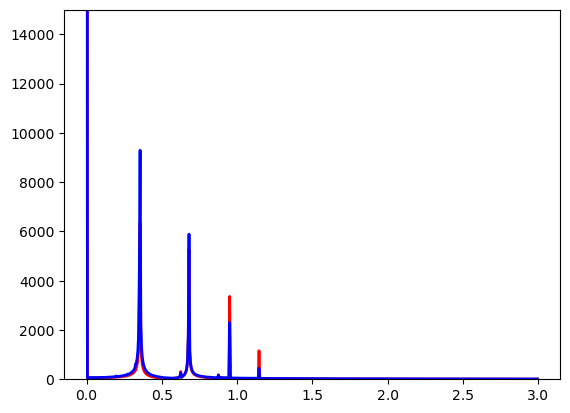

In [34]:
freqs, amps1 = interpolated_fft(time_list, ExV_t, fs=50, kind='linear', fmax=fmax)
freqs, amps = interpolated_fft(time_list, ExV_t_trunc, fs=50, kind='linear', fmax=fmax)
plt.ylim(0,1.5e4)
plt.plot(freqs, amps1,label='real', color='red', linewidth=2)
plt.plot(freqs, amps,label='real', color='blue', linewidth=2)

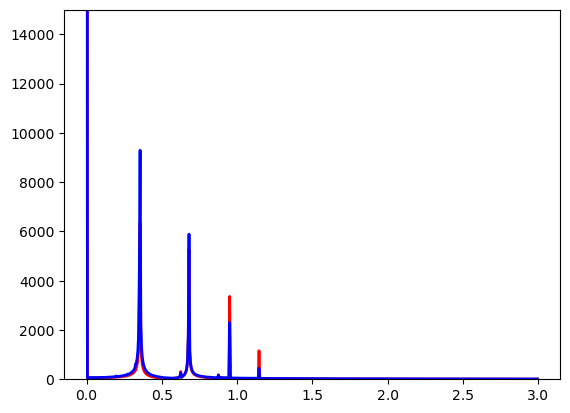

In [112]:
freqs, amps1 = interpolated_fft(time_list, np.real(ExV_t), fs=50, kind='linear', fmax=fmax)
freqs, amps = interpolated_fft(time_list, np.real(ExV_t_trunc), fs=50, kind='linear', fmax=fmax)
plt.ylim(0,1.5e4)
plt.plot(freqs, amps1,label='real', color='red', linewidth=2)
plt.plot(freqs, amps,label='real', color='blue', linewidth=2)